# Toy time-dependent com produção e wrong-tag

Este exemplo gera a amostra conjunta `(Dalitz, tempo, tag)` usando a mesma densidade time-dependent do fit. `production_fraction` controla a fração verdadeira de D0 e `wrong_tag` troca parte dos tags observados.

In [18]:
import jax.numpy as jnp
from dalitzplotfitter import (
    DecayChannel, DecayModel, NeutralMesonMixing, Parameter, RealImag,
    RelativisticBreitWigner, Resonance, TimeDependentFitSession,
    ZemachP, generate_time_dependent_toy,
)

channel = DecayChannel("D0", ("K(S)0", "pi+", "pi-"))
resonance = Resonance(
    "Kstar", (0,1), RealImag(1.0, 0.0),
    lineshape=RelativisticBreitWigner(), angular=ZemachP(),
    mass=0.895, width=0.05, spin=1, normalize_component=False,
)
model = DecayModel(
    channel, [resonance], normalize_components=False,
    normalization_method="square-dalitz", normalization_resolution=20,
)
seed_data = model.generate_phase_space(32, seed=1, include_momenta=False)
seed_session = TimeDependentFitSession(
    model, seed_data, jnp.linspace(0.05, 1.0, seed_data.size),
    jnp.asarray([1, -1] * (seed_data.size // 2)),
    NeutralMesonMixing(0.08, 0.04, 0.4103), time_range=(0.0, 4.0),
)

## Geração conjunta

O resultado contém `toy.data`, `toy.times`, `toy.tags` e `toy.true_tags`. O tempo e o Dalitz não são gerados independentemente: os pesos de importância usam a densidade física com mixing.

In [19]:
toy = generate_time_dependent_toy(
    seed_session, 5_000, production_fraction=0.65, wrong_tag=0.08,
    seed=20260923, proposal_size=100_000,
)

print("events:", toy.data.size)
print("observed P(tag=+1):", float(jnp.mean(toy.tags == 1)))
print("true P(D0):", float(jnp.mean(toy.true_tags == 1)))
print("time range:", float(toy.times.min()), float(toy.times.max()))

events: 5000
observed P(tag=+1): 0.5920000076293945
true P(D0): 0.6279999613761902
time range: 5.428360416957585e-05 3.5972693462607537


## Ajuste

O ajuste usa os mesmos eventos e deve recuperar a estrutura temporal dentro da incerteza estatística. Para recuperar uma assimetria de produção no próprio likelihood, use o modo `extended=True` e `production_fraction`.

In [20]:
fit_session = TimeDependentFitSession(
    model, toy.data, toy.times, toy.tags,
    NeutralMesonMixing(
        Parameter("mix.x", 0.03, bounds=(-0.2, 0.2)),
        Parameter("mix.y", -0.02, bounds=(-0.2, 0.2)),
        0.4103,
    ),
    time_range=(0.0, 4.0), wrong_tag=0.08,
)
result = fit_session.fit(strategy=1, hesse=False, ncall=200)
fit_session.print_result(result)

valid=True  NLL=-1383.742811
parameter                           value            error
mix.x                            0.113216        0.0272864
mix.y                            0.096141        0.0197293


{'mix.x': 0.11321628946921665, 'mix.y': 0.09614103284420207}

## Plots do toy

Os painéis abaixo mostram a população no plano Dalitz, a distribuição de tempo por tag observado, a migração causada pelo wrong-tag e a taxa de wrong-tag em bins de tempo.

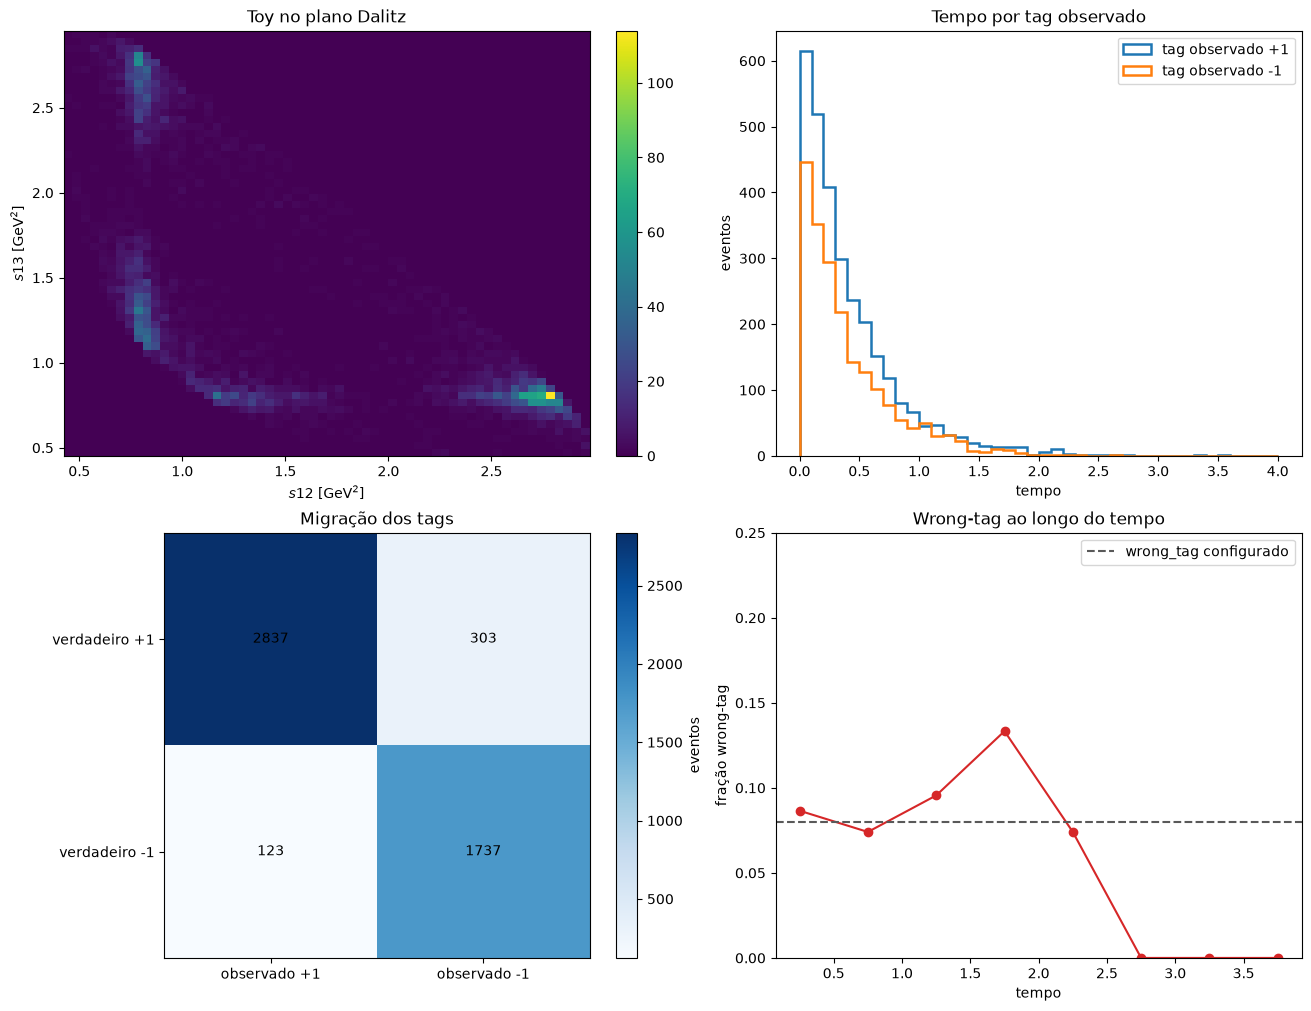

wrong-tag observado: 0.085


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from dalitzplotfitter import plot_dalitz

observed_tags = np.asarray(toy.tags)
true_tags = np.asarray(toy.true_tags)
times = np.asarray(toy.times)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
plot_dalitz(
    toy.data,
    x="s12",
    y="s13",
    bins=60,
    ax=axes[0, 0],
    title="Toy no plano Dalitz",
    colorbar=True,
)

for tag, label, color in ((1, "tag observado +1", "tab:blue"), (-1, "tag observado -1", "tab:orange")):
    axes[0, 1].hist(
        times[observed_tags == tag],
        bins=40,
        range=(0.0, 4.0),
        histtype="step",
        linewidth=1.8,
        label=label,
        color=color,
    )
axes[0, 1].set(xlabel="tempo", ylabel="eventos", title="Tempo por tag observado")
axes[0, 1].legend()

confusion = np.zeros((2, 2), dtype=int)
for true_tag, observed_tag in ((1, 1), (1, -1), (-1, 1), (-1, -1)):
    confusion[0 if true_tag == 1 else 1, 0 if observed_tag == 1 else 1] = np.count_nonzero(
        (true_tags == true_tag) & (observed_tags == observed_tag)
    )
image = axes[1, 0].imshow(confusion, cmap="Blues")
axes[1, 0].set(
    xticks=(0, 1),
    xticklabels=("observado +1", "observado -1"),
    yticks=(0, 1),
    yticklabels=("verdadeiro +1", "verdadeiro -1"),
    title="Migração dos tags",
)
for row in range(2):
    for column in range(2):
        axes[1, 0].text(column, row, confusion[row, column], ha="center", va="center")
fig.colorbar(image, ax=axes[1, 0], label="eventos")

edges = np.linspace(0.0, 4.0, 9)
centers = 0.5 * (edges[:-1] + edges[1:])
wrong = (observed_tags != true_tags).astype(float)
counts = np.histogram(times, bins=edges)[0]
wrong_counts = np.histogram(times, bins=edges, weights=wrong)[0]
wrong_rate = np.divide(
    wrong_counts,
    counts,
    out=np.full(edges.size - 1, np.nan),
    where=counts > 0,
)
axes[1, 1].plot(centers, wrong_rate, "o-", color="tab:red")
axes[1, 1].axhline(0.08, color="0.35", linestyle="--", label="wrong_tag configurado")
axes[1, 1].set(xlabel="tempo", ylabel="fração wrong-tag", ylim=(0.0, 0.25), title="Wrong-tag ao longo do tempo")
axes[1, 1].legend()

plt.show()
print(f"wrong-tag observado: {wrong.mean():.3f}")